In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("C:/Users/12sha/OneDrive/Desktop/MP_6thSem/Synthetic_industrial_sensor_data_V4.csv")

In [10]:
df.head()

,time,temperature,vibration,sound,anomaly
0,0,30.250858,0.070158,44.624015,0.0
1,1,29.922393,0.363687,45.992177,0.0
2,2,30.302469,0.395606,45.199860,0.0
3,3,30.742020,0.920135,45.610246,0.0
4,4,29.866523,0.648560,46.283103,0.0


In [11]:
df.tail()

,time,temperature,vibration,sound,anomaly
19995,19995,72.581634,1.573947,49.331767,1.0
19996,19996,73.317383,1.735982,52.006080,1.0
19997,19997,71.532026,1.762616,51.713412,1.0
19998,19998,74.226288,2.203738,50.263507,1.0
19999,19999,71.019018,2.211087,52.426691,1.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         20000 non-null  int64  
 1   temperature  20000 non-null  float64
 2   vibration    20000 non-null  float64
 3   sound        20000 non-null  float64
 4   anomaly      20000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 781.4 KB


In [12]:
df.describe()

,time,temperature,vibration,sound,anomaly
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,50.593913,1.132106,48.489869,0.205000
std,5773.647028,12.112190,1.014087,2.517299,0.403712
min,0.000000,28.763223,-1.485769,41.203611,0.000000
25%,4999.750000,40.338438,0.409870,46.665917,0.000000
50%,9999.500000,50.654197,1.120006,48.442532,0.000000
75%,14999.250000,60.350506,1.859927,50.233613,0.000000
max,19999.000000,74.226288,4.202955,57.368212,1.000000


In [19]:
# Class distribution
df['anomaly'].value_counts()

anomaly
0.0    15900
1.0     4100
Name: count, dtype: int64

#### Checking for outliers

In [22]:
# Checking for Vibration outliers
Q1 = df["vibration"].quantile(0.25)
Q3 = df["vibration"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
outliers = df[(df['vibration']> upper_bound) | (df['vibration']< lower_bound)]
print(len(outliers))

2


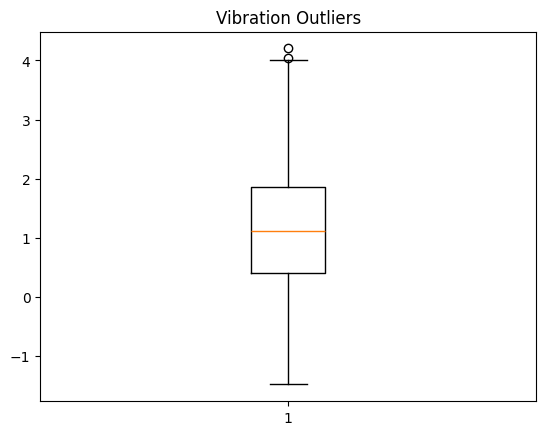

In [21]:
plt.boxplot(df['vibration'])
plt.title("Vibration Outliers")
plt.show()

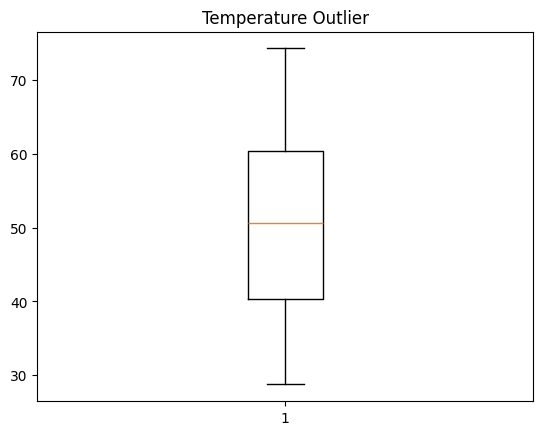

In [23]:
# Checking for temperature outliers
plt.boxplot(df["temperature"])
plt.title("Temperature Outlier")
plt.show()

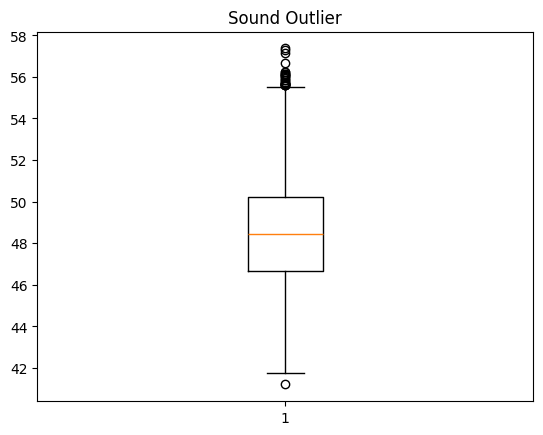

In [24]:
# Checking for Sound Outliers
plt.boxplot(df["sound"])
plt.title("Sound Outlier")
plt.show()

In [25]:
Q1 = df["sound"].quantile(0.25)
Q3 = df["sound"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
outliers = df[(df['sound']> upper_bound) | (df['sound']< lower_bound)]
print(len(outliers))

26


### Univariate Analysis

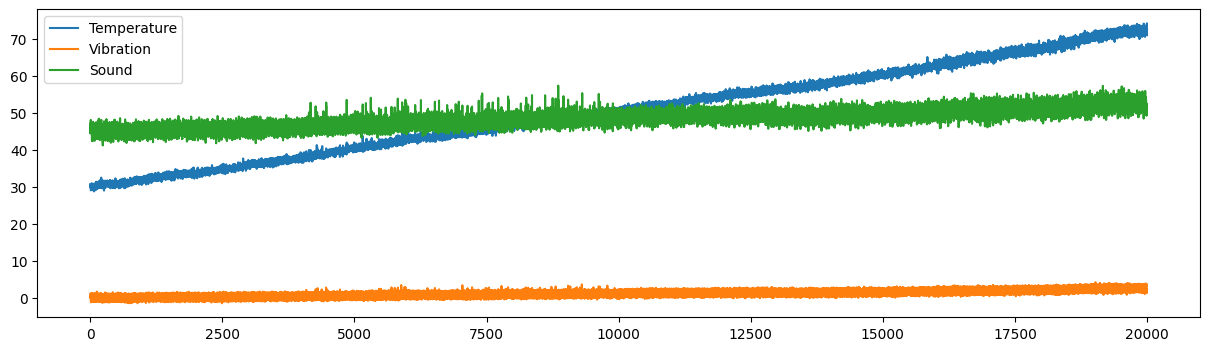

In [13]:
plt.figure(figsize= (15, 4))
plt.plot(df['temperature'], label = 'Temperature')
plt.plot(df['vibration'], label = 'Vibration')
plt.plot(df['sound'], label = 'Sound')

plt.legend()
plt.show()

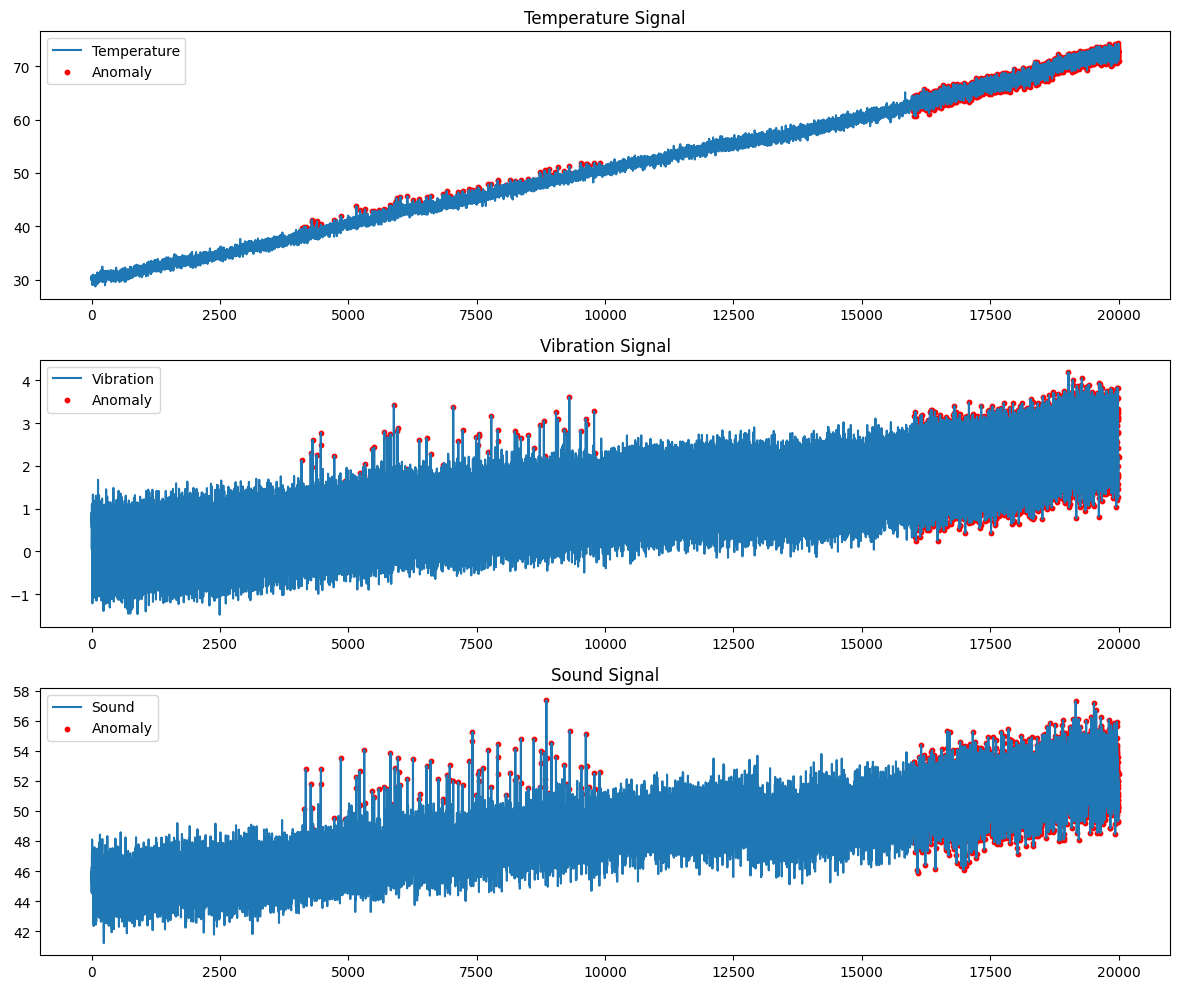

In [17]:
anoms = df[df["anomaly"] == 1]
fig, axes = plt.subplots(3, 1, figsize = (12, 10))

# Temperature
axes[0].plot(df["temperature"], label = "Temperature")
axes[0].scatter(anoms.index, anoms["temperature"], color= 'red', s= 10, label= "Anomaly")
axes[0].set_title("Temperature Signal")
axes[0].legend()

# Vibration
axes[1].plot(df["vibration"], label = "Vibration")
axes[1].scatter(anoms.index, anoms["vibration"], color= 'red', s= 10, label= "Anomaly")
axes[1].set_title("Vibration Signal")
axes[1].legend()

# Sound
axes[2].plot(df["sound"], label = "Sound")
axes[2].scatter(anoms.index, anoms["sound"], color= 'red', s= 10, label= "Anomaly")
axes[2].set_title("Sound Signal")
axes[2].legend()

plt.tight_layout()
plt.show()

### Distribution Plots (Histogram + KDE (Kernel Density Estimation))

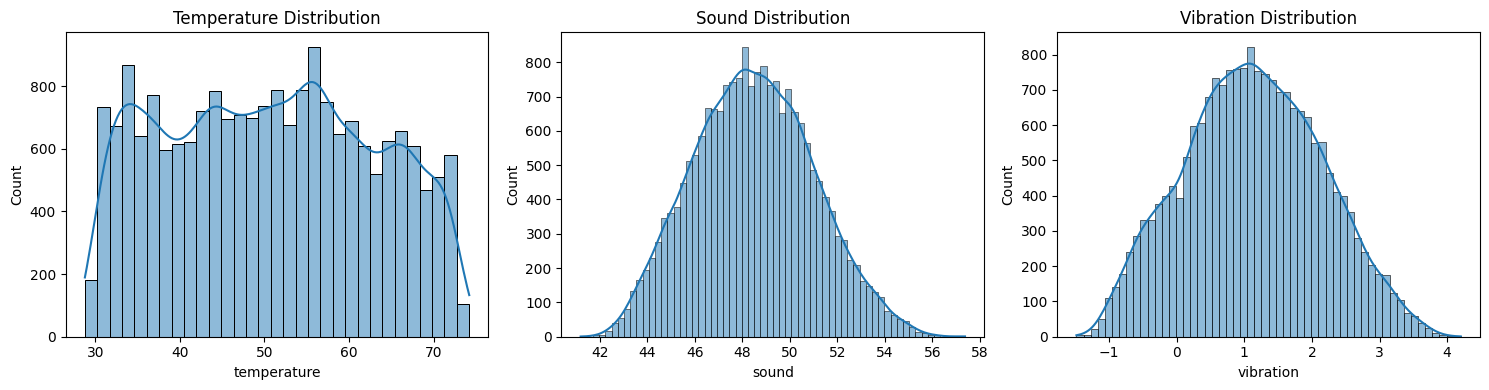

In [26]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['temperature'], kde= True)
plt.title("Temperature Distribution")

plt.subplot(1, 3, 2)
sns.histplot(df['sound'], kde= True)
plt.title("Sound Distribution")

plt.subplot(1, 3, 3)
sns.histplot(df['vibration'], kde= True)
plt.title("Vibration Distribution")

plt.tight_layout()
plt.show()

### Time- Series Behavior

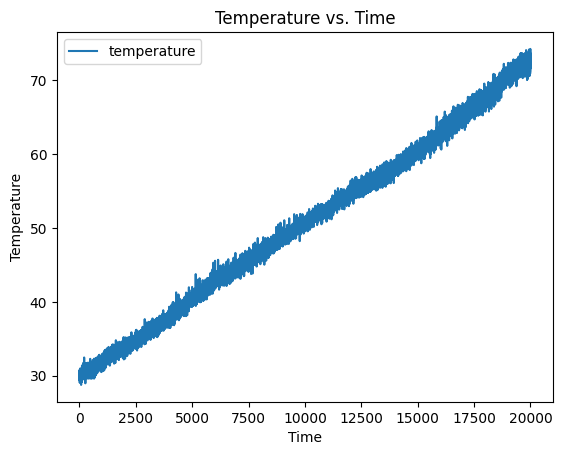

In [29]:
# Temperature vs Time graph
df.plot(x = 'time', y = 'temperature', kind= 'line', title= 'Temperature vs. Time')
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

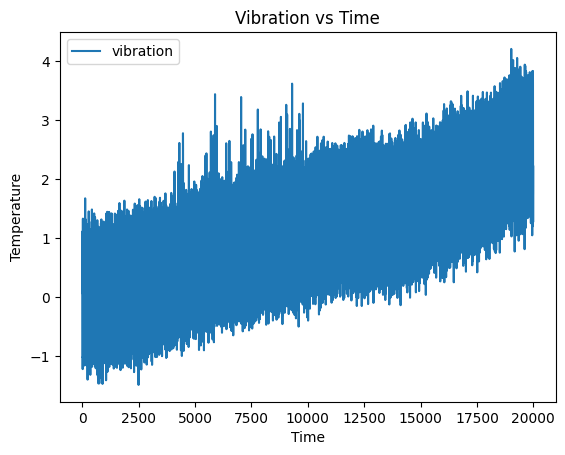

In [35]:
# Vibration vs Time Graph

df.plot(x = "time", y = "vibration", kind = 'line', title = "Vibration vs Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

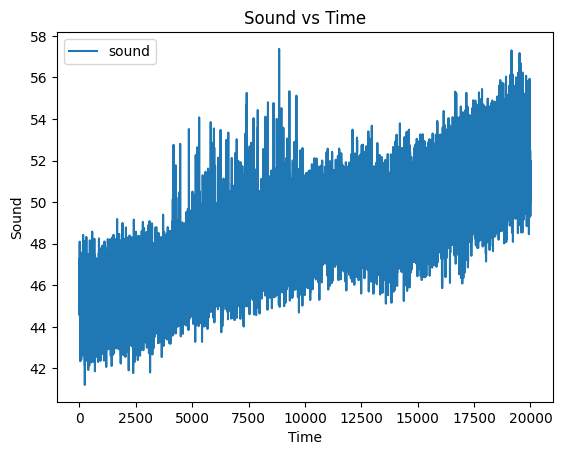

In [36]:
# Sound vs Time
df.plot(x = 'time', y = 'sound', kind = 'line', title = "Sound vs Time")
plt.xlabel("Time")
plt.ylabel("Sound")
plt.show()

## Adding Rolling Statistics

In [2]:
data = pd.read_csv("C:/Users/12sha/OneDrive/Desktop/MP_6thSem/data/Synthetic_industrial_sensor_data_V4.1.csv")

In [3]:
data.head()

,time,temperature,vibration,sound,anomaly
0,0,30.250858,0.070158,44.624015,0.0
1,1,29.922393,0.363687,45.992177,0.0
2,2,30.302469,0.395606,45.199860,0.0
3,3,30.742020,0.920135,45.610246,0.0
4,4,29.866523,0.648560,46.283103,0.0


#### Rolling Mean
A rolling mean smooths short-term fluctuations and reveals the underlying trend. It answers: "What does the signal look like if we ignore small noise?"

In [4]:
data["temp_roll_mean"] = data["temperature"].rolling(window= 50).mean()
data["vib_roll_mean"] = data["vibration"].rolling(window = 50).mean()
data["sound_roll_mean"] = data["sound"].rolling(window= 50).mean()

In [5]:
data.head()

,time,temperature,vibration,sound,anomaly,temp_roll_mean,vib_roll_mean,sound_roll_mean
0,0,30.250858,0.070158,44.624015,0.0,NaN,NaN,NaN
1,1,29.922393,0.363687,45.992177,0.0,NaN,NaN,NaN
2,2,30.302469,0.395606,45.199860,0.0,NaN,NaN,NaN
3,3,30.742020,0.920135,45.610246,0.0,NaN,NaN,NaN
4,4,29.866523,0.648560,46.283103,0.0,NaN,NaN,NaN


In [6]:
data.tail()

,time,temperature,vibration,sound,anomaly,temp_roll_mean,vib_roll_mean,sound_roll_mean
19995,19995,72.581634,1.573947,49.331767,1.0,72.300908,2.515877,52.432891
19996,19996,73.317383,1.735982,52.006080,1.0,72.312093,2.480362,52.450743
19997,19997,71.532026,1.762616,51.713412,1.0,72.297771,2.451084,52.416227
19998,19998,74.226288,2.203738,50.263507,1.0,72.331737,2.429215,52.410367
19999,19999,71.019018,2.211087,52.426691,1.0,72.308339,2.414155,52.387356


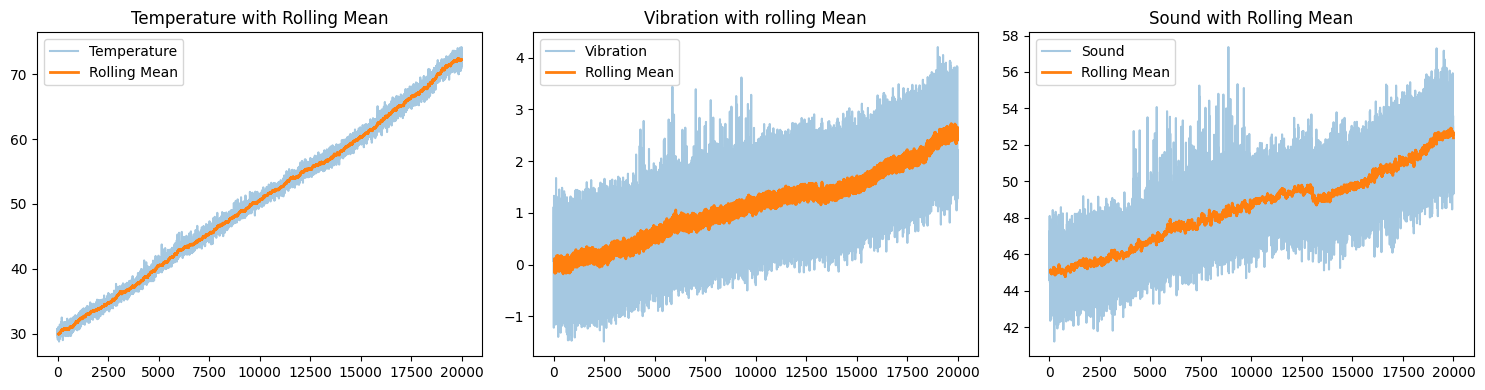

In [7]:
plt.figure(figsize = (15, 4))
plt.subplot(1, 3, 1)
plt.plot(data['temperature'], alpha= 0.4, label= "Temperature")
plt.plot(data['temp_roll_mean'], linewidth = 2, label = "Rolling Mean")
plt.legend()
plt.title("Temperature with Rolling Mean")

plt.subplot(1, 3, 2)
plt.plot(data['vibration'], alpha= 0.4, label= "Vibration")
plt.plot(data['vib_roll_mean'], linewidth= 2, label= "Rolling Mean")
plt.legend()
plt.title("Vibration with rolling Mean")

plt.subplot(1, 3, 3)
plt.plot(data['sound'], alpha= 0.4, label= "Sound")
plt.plot(data['sound_roll_mean'], linewidth= 2, label = "Rolling Mean")
plt.legend()
plt.title("Sound with Rolling Mean")

plt.tight_layout()
plt.show()

#### Rolling Standard Deviation(Signal Stability)
Rolling standard deviation measures how volatile the signal is locally.

In [8]:
data['temp_roll_std'] = data['temperature'].rolling(window = 50).std()
data['vib_roll_std'] = data['vibration'].rolling(window = 50).std()
data['sound_roll_std'] = data['sound'].rolling(window = 50).std()

In [9]:
data.tail()

,time,temperature,vibration,sound,anomaly,temp_roll_mean,vib_roll_mean,sound_roll_mean,temp_roll_std,vib_roll_std,sound_roll_std
19995,19995,72.581634,1.573947,49.331767,1.0,72.300908,2.515877,52.432891,0.693027,0.779748,1.629484
19996,19996,73.317383,1.735982,52.006080,1.0,72.312093,2.480362,52.450743,0.704967,0.773883,1.619593
19997,19997,71.532026,1.762616,51.713412,1.0,72.297771,2.451084,52.416227,0.713515,0.772768,1.616485
19998,19998,74.226288,2.203738,50.263507,1.0,72.331737,2.429215,52.410367,0.763378,0.763754,1.623878
19999,19999,71.019018,2.211087,52.426691,1.0,72.308339,2.414155,52.387356,0.785455,0.760409,1.615134


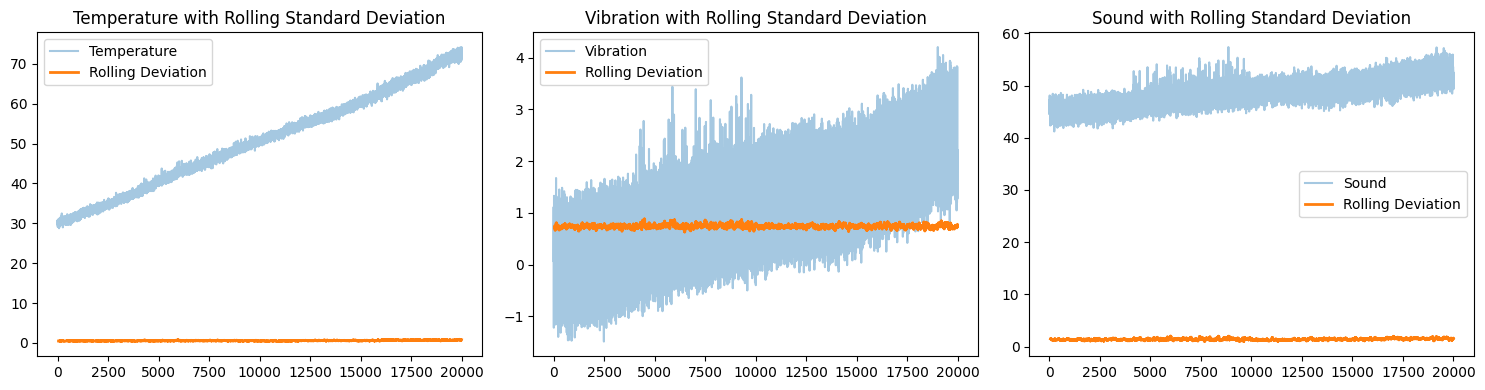

In [10]:
plt.figure(figsize = (15, 4))
plt.subplot(1, 3, 1)
plt.plot(data['temperature'], alpha= 0.4, label= "Temperature")
plt.plot(data['temp_roll_std'], linewidth = 2, label = "Rolling Deviation")
plt.legend()
plt.title("Temperature with Rolling Standard Deviation")

plt.subplot(1, 3, 2)
plt.plot(data['vibration'], alpha= 0.4, label= "Vibration")
plt.plot(data['vib_roll_std'], linewidth= 2, label= "Rolling Deviation")
plt.legend()
plt.title("Vibration with Rolling Standard Deviation")

plt.subplot(1, 3, 3)
plt.plot(data['sound'], alpha= 0.4, label= "Sound")
plt.plot(data['sound_roll_std'], linewidth= 2, label = "Rolling Deviation")
plt.legend()
plt.title("Sound with Rolling Standard Deviation")

plt.tight_layout()
plt.show()

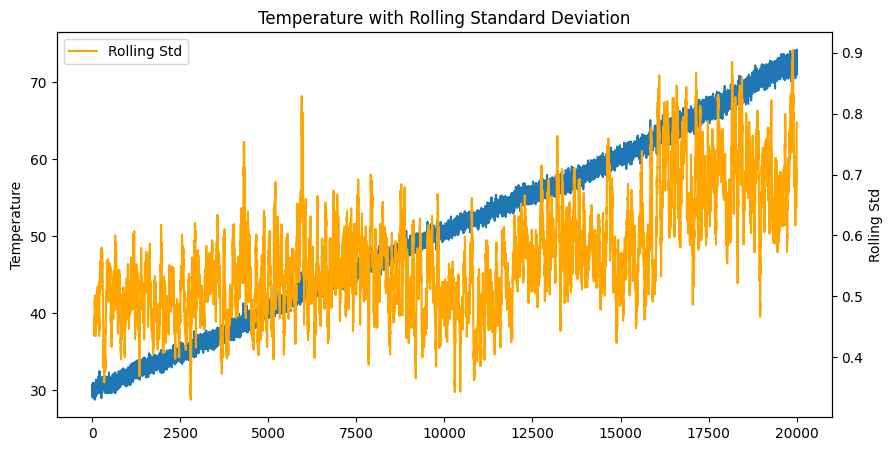

In [11]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(data["temperature"], label="Temperature")
ax1.set_ylabel("Temperature")

ax2 = ax1.twinx()
ax2.plot(data["temp_roll_std"], color="orange", label="Rolling Std")
ax2.set_ylabel("Rolling Std")

plt.title("Temperature with Rolling Standard Deviation")
plt.legend()
plt.show()

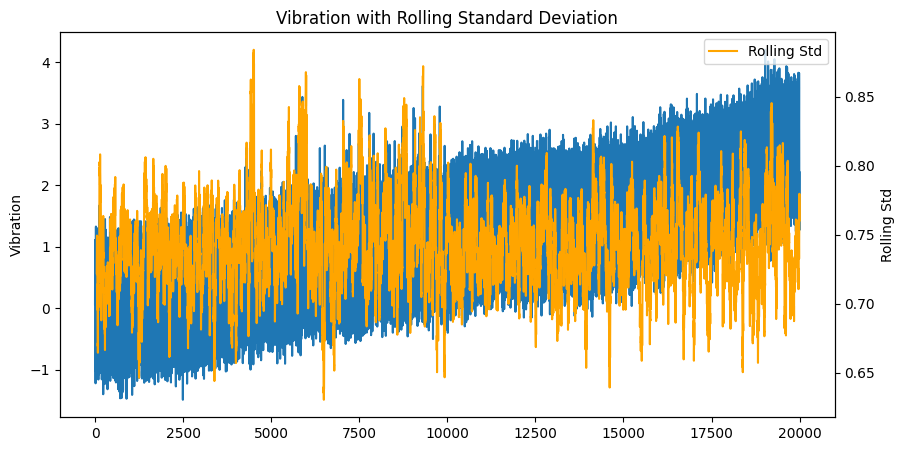

In [12]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(data["vibration"], label="Vibration")
ax1.set_ylabel("Vibration")

ax2 = ax1.twinx()
ax2.plot(data["vib_roll_std"], color="orange", label="Rolling Std")
ax2.set_ylabel("Rolling Std")

plt.title("Vibration with Rolling Standard Deviation")
plt.legend()
plt.show()

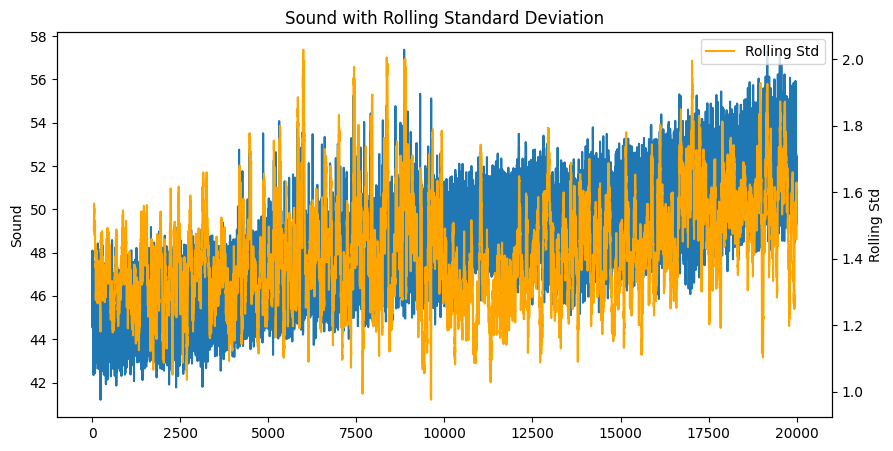

In [13]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(data["sound"], label="Sound")
ax1.set_ylabel("Sound")

ax2 = ax1.twinx()
ax2.plot(data["sound_roll_std"], color="orange", label="Rolling Std")
ax2.set_ylabel("Rolling Std")

plt.title("Sound with Rolling Standard Deviation")
plt.legend()
plt.show()

In [14]:
data = data.dropna()

In [16]:
data.to_csv("updated_data.csv", index= False)

In [15]:
data.head()

,time,temperature,vibration,sound,anomaly,temp_roll_mean,vib_roll_mean,sound_roll_mean,temp_roll_std,vib_roll_std,sound_roll_std
49,49,29.188947,-0.015172,46.564832,0.0,29.920146,0.108273,45.009719,0.460476,0.722081,1.487562
50,50,30.241770,-0.413303,47.097820,0.0,29.919964,0.098604,45.059196,0.460345,0.725829,1.515351
51,51,29.909556,-0.376216,44.991851,0.0,29.919708,0.083806,45.039189,0.460347,0.727854,1.509373
52,52,29.759116,-0.873411,46.083147,0.0,29.908841,0.058425,45.056855,0.457532,0.738802,1.516445
53,53,30.409837,-1.086053,46.305419,0.0,29.902197,0.018301,45.070758,0.447488,0.745496,1.524786
